# Notebook 05g — RF Gallery + Dataset for m=1 Simple Cells

Visualisation and dataset export for all 31 verified m=1 neurons.

**Cell order:**
1. Imports
2. Paths & data loading
3. `batch_get_rf_maps_safe` definition
4. Load population CSV + rebuild m_final
5. m_final merge (nb07 protected)
6. Load RF maps
7. Refit m=1 Gaussian derivatives + φ estimation
8. Build `m1_dataset` with neuron names → save pickle + CSV
9. Fig 1: gallery sorted by κ
10. Fig 2: gallery sorted by φ


In [1]:
import sys, warnings, time, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RidgeCV, Ridge
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    fit_rf_by_order,
    gaussian_deriv_m1,
    estimate_phi_from_lobes,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Imports OK')


Imports OK


In [2]:
# ---------------------------------------------------------------------------
# Paths — identical to nb05d Cell 2
# ---------------------------------------------------------------------------
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'

nb05d_dir = outputs_dir / 'order_full_v2'   # v2 rerun CSVs + judgements
nb07_dir  = outputs_dir / 'order_full'       # nb07 manual judgements
nb09_dir  = outputs_dir / 'nb09'             # nb09 manual judgements

gallery_dir = nb05d_dir / 'rf_gallery'
gallery_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

batch_df       = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df      = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded     = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
complete_ids   = set(container_meta['container_id'].tolist())

session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()

container_to_exp  = dict(zip(session_c['experiment_container_id'], session_c['id']))
container_meta_d  = dict(zip(session_c['experiment_container_id'],
                              zip(session_c['cre_line'], session_c['imaging_depth'])))

print(f'Session C experiments: {len(session_c)}')
print(f'Containers: {len(container_to_exp)}')


Session C experiments: 17
Containers: 17


In [3]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps_safe — canonical RF map loader (handles AllenSDK sort quirk)
# ---------------------------------------------------------------------------
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    from rf_analysis.sparse_noise import _build_design_matrix, _pixel_size, _LAMBDA_GRID
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError('No requested cell_ids found in experiment.')

    stim_name = next((s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if stim_name is None:
        raise ValueError('No sparse noise stimulus.')

    stim_table = dataset.get_stimulus_table(stim_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stim_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stim_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few valid presentations.')

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

print('batch_get_rf_maps_safe defined')


batch_get_rf_maps_safe defined


In [4]:
# ---------------------------------------------------------------------------
# Load v2 population CSV and rebuild m_final
# ---------------------------------------------------------------------------
csv_files = sorted(nb05d_dir.glob('rf_params_order_v2_container_*.csv'))
print(f'Found {len(csv_files)} container CSVs')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    if 'container_id' not in df.columns:
        df['container_id'] = int(f.stem.split('_')[-1])
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)

for col in ['sigma', 'theta', 'kappa', 'r_squared', 'sigma_x', 'sigma_y',
            'x0', 'y0', 'phi', 'phi_confidence', 'theta_hybrid',
            'cortex_x_um', 'cortex_y_um', 'r2_m0', 'r2_m1', 'r2_m2',
            'delta_r2_vs_m0']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

all_df['sigma_major'] = all_df[['sigma_x', 'sigma_y']].max(axis=1)
all_df['sigma_minor'] = all_df[['sigma_x', 'sigma_y']].min(axis=1)
all_df['log_sigma']   = np.log10(all_df['sigma'])
all_df['log_kappa']   = np.log(all_df['kappa'])

all_df.loc[all_df['derivative_order'] == 0, 'theta_hybrid'] =     all_df.loc[all_df['derivative_order'] == 0, 'theta']
all_df.loc[all_df['derivative_order'] == 2, 'theta_hybrid'] =     all_df.loc[all_df['derivative_order'] == 2, 'theta']

print(f'Total neurons: {len(all_df):,}  |  {all_df["container_id"].nunique()} containers')


Found 17 container CSVs
Total neurons: 1,017  |  17 containers


In [5]:
# ---------------------------------------------------------------------------
# m_final merge — nb07 m=1 calls are protected; later reviews cannot demote them
# ---------------------------------------------------------------------------
judged      = {}
nb07_m1_ids = set()
nb07_path   = nb07_dir / 'manual_m_judgements.csv'
if nb07_path.exists():
    jdf = pd.read_csv(nb07_path)
    jdf = jdf[jdf['m_manual'] >= 0]
    for _, r in jdf.iterrows():
        judged[int(r['cell_id'])] = int(r['m_manual'])
        if int(r['m_manual']) == 1:
            nb07_m1_ids.add(int(r['cell_id']))
    print(f'nb07: {len(jdf)} judgements  ({len(nb07_m1_ids)} m=1 protected)')
else:
    print('nb07: not found')

later_sources = [
    (nb09_dir  / 'nb09_review_judgements.csv',       'nb09',          'm_manual'),
    (nb05d_dir / 'targeted_review_judgements.csv',   'targeted',      'm_manual'),
    (nb05d_dir / 'unreviewed_m1_judgements.csv',     'unreviewed_m1', 'm_manual'),
    (nb05d_dir / 'rescue_review_judgements.csv',     'rescue',        'm_final'),
]
for path, label, col in later_sources:
    if not path.exists():
        print(f'  {label}: not found — skipping')
        continue
    jdf     = pd.read_csv(path)
    jdf     = jdf[jdf[col] >= 0]
    applied = skipped = 0
    for _, r in jdf.iterrows():
        cid   = int(r['cell_id'])
        m_new = int(r[col])
        if cid in nb07_m1_ids and m_new == 0:
            skipped += 1
            continue
        judged[cid] = m_new
        applied += 1
    print(f'{label}: {applied} applied, {skipped} skipped (protected nb07 m=1)')

all_df['m_manual']          = all_df['cell_id'].map(judged)
all_df['manually_verified'] = all_df['cell_id'].isin(judged)
all_df['m_final'] = np.where(
    all_df['m_manual'].notna(),
    all_df['m_manual'],
    all_df['derivative_order']
).astype(int)

if 'delta_r2_vs_m0' in all_df.columns:
    demote = (
        (all_df['m_final'] == 2) &
        (~all_df['manually_verified']) &
        (all_df['delta_r2_vs_m0'] < 0.10)
    )
    all_df.loc[demote, 'm_final'] = 0
    print(f'Auto-demoted {demote.sum()} unreviewed m=2 → m=0')

m1 = all_df[all_df['m_final'] == 1].copy()
print(f'\nm=1: {len(m1)}  (target: 31)')


nb07: 225 judgements  (13 m=1 protected)
nb09: 111 applied, 1 skipped (protected nb07 m=1)
targeted: 57 applied, 0 skipped (protected nb07 m=1)
unreviewed_m1: 1 applied, 0 skipped (protected nb07 m=1)
  rescue: not found — skipping
Auto-demoted 102 unreviewed m=2 → m=0

m=1: 31  (target: 31)


In [6]:
# ---------------------------------------------------------------------------
# Load RF maps for all m=1 neurons
# ---------------------------------------------------------------------------
rf_map_cache  = {}
dataset_cache = {}

by_container = m1.groupby('container_id')['cell_id'].apply(list).to_dict()
print(f'Loading {len(m1)} neurons across {len(by_container)} containers')

t_start = time.time()
for i, (container_id, cids) in enumerate(by_container.items()):
    if container_id not in container_to_exp:
        print(f'  [{i+1}/{len(by_container)}] {container_id}: not in session_c — skip')
        continue
    print(f'  [{i+1}/{len(by_container)}] Container {container_id} '
          f'({len(cids)} neurons) ...', end=' ', flush=True)
    try:
        if container_id not in dataset_cache:
            dataset_cache[container_id] = boc.get_ophys_experiment_data(
                container_to_exp[container_id])
        maps = batch_get_rf_maps_safe(dataset_cache[container_id], cids)
        rf_map_cache.update(maps)
        print(f'{len(maps)} loaded  ({time.time()-t_start:.0f}s)')
    except Exception as e:
        print(f'FAIL — {e}')

print(f'\nTotal RF maps loaded: {len(rf_map_cache)}/{len(m1)}')


Loading 31 neurons across 13 containers
  [1/13] Container 511507650 (1 neurons) ... 1 loaded  (45s)
  [2/13] Container 511509529 (2 neurons) ... 2 loaded  (150s)
  [3/13] Container 511510670 (2 neurons) ... 2 loaded  (245s)
  [4/13] Container 511510718 (2 neurons) ... 2 loaded  (399s)
  [5/13] Container 511510855 (5 neurons) ... 5 loaded  (459s)
  [6/13] Container 650389885 (2 neurons) ... 2 loaded  (507s)
  [7/13] Container 652842570 (3 neurons) ... 3 loaded  (550s)
  [8/13] Container 653125128 (5 neurons) ... 5 loaded  (650s)
  [9/13] Container 661437138 (1 neurons) ... 1 loaded  (704s)
  [10/13] Container 661732156 (2 neurons) ... 2 loaded  (752s)
  [11/13] Container 666589599 (1 neurons) ... 1 loaded  (798s)
  [12/13] Container 680156909 (1 neurons) ... 1 loaded  (845s)
  [13/13] Container 688678764 (4 neurons) ... 4 loaded  (924s)

Total RF maps loaded: 31/31


In [7]:
# ---------------------------------------------------------------------------
# Refit m=1 Gaussian derivative + compute phi from lobe geometry
#
# fit_results: cell_id -> (params, quality, fitted_map, pix_size,
#                          phi_fresh, phi_conf, angle_corr_profile)
#
# angle_corr_profile: 18-element array of |Pearson r| vs smoothed RF for
# models at 0, 10, 20, ... 170 degrees (best of both sigma orderings at
# each step).  Stored for post-hoc orientation landscape diagnostics.
# ---------------------------------------------------------------------------
from scipy.ndimage import gaussian_filter as _gf

N_RANDOM_STARTS = 15
SMOOTH_SIGMA    = 0.75
GRID_ANGLES     = np.arange(0, 180, 10)   # 18 steps

fit_results = {}

for idx, row in m1.reset_index(drop=True).iterrows():
    cid = int(row['cell_id'])
    if cid not in rf_map_cache:
        print(f'  [{idx+1}/{len(m1)}] cell {cid}: no RF map — skip')
        continue
    rf_map, pix = rf_map_cache[cid]
    rf_on  = np.maximum(rf_map,  0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    grid_h, grid_w = rf_map.shape
    Y_g, X_g = np.mgrid[0:grid_h, 0:grid_w].astype(float)
    xy = (X_g, Y_g)
    try:
        p, q = fit_rf_by_order(
            rf_on, rf_off, m=1,
            pixel_size_deg=pix,
            smooth_sigma=SMOOTH_SIGMA,
            n_random_starts=N_RANDOM_STARTS,
            seed=cid,
        )

        phi_fresh, phi_conf = estimate_phi_from_lobes(
            rf_on, rf_off, m=1,
            pixel_size_deg=pix,
            smooth_sigma=SMOOTH_SIGMA,
        )

        su_px = p['sigma_x'] / pix
        sv_px = p['sigma_y'] / pix
        x0_px = p['x0']     / pix
        y0_px = p['y0']     / pix
        A_abs = abs(p['amplitude'])

        rf_smooth_corr = _gf(rf_map, sigma=SMOOTH_SIGMA)
        rf_flat   = rf_smooth_corr.ravel()
        rf_center = rf_flat - rf_flat.mean()
        rf_norm   = np.linalg.norm(rf_center)

        # ── Orientation correlation profile (diagnostic) ──────────────────
        # For each angle in 0-170 at 10 deg steps, record the best
        # |correlation| across both sigma orderings.  Sharp peak = reliable
        # orientation; flat landscape = unreliable (noise or low kappa).
        angle_corr_profile = np.full(len(GRID_ANGLES), np.nan)
        for i_ang, angle_deg in enumerate(GRID_ANGLES):
            th_g = np.deg2rad(angle_deg)
            best_for_angle = 0.0
            for su_t, sv_t in [(su_px, sv_px), (sv_px, su_px)]:
                cand = [A_abs, x0_px, y0_px, su_t, sv_t, th_g, 0.0]
                m_f = gaussian_deriv_m1(xy, *cand).ravel()
                m_c = m_f - m_f.mean()
                m_n = np.linalg.norm(m_c)
                if rf_norm < 1e-12 or m_n < 1e-12:
                    continue
                best_for_angle = max(best_for_angle,
                                     abs(float(np.dot(rf_center, m_c)) / (rf_norm * m_n)))
            angle_corr_profile[i_ang] = best_for_angle

        # ── Full candidate set for best display model ─────────────────────
        candidates = []
        th_theta = np.deg2rad(p['theta'])
        candidates.append([p['amplitude'], x0_px, y0_px, su_px, sv_px, th_theta, 0.0])
        candidates.append([p['amplitude'], x0_px, y0_px, sv_px, su_px, th_theta, 0.0])

        if phi_fresh is not None and not np.isnan(float(phi_fresh)):
            th_phi = np.deg2rad(phi_fresh)
            candidates.append([A_abs, x0_px, y0_px, su_px, sv_px, th_phi, 0.0])
            candidates.append([A_abs, x0_px, y0_px, sv_px, su_px, th_phi, 0.0])

        for angle_deg in GRID_ANGLES:
            th_g = np.deg2rad(angle_deg)
            candidates.append([A_abs, x0_px, y0_px, su_px, sv_px, th_g, 0.0])
            candidates.append([A_abs, x0_px, y0_px, sv_px, su_px, th_g, 0.0])

        best_corr = -1.0
        best_popt = candidates[0]
        for cand in candidates:
            m_flat = gaussian_deriv_m1(xy, *cand).ravel()
            m_center = m_flat - m_flat.mean()
            m_norm = np.linalg.norm(m_center)
            if rf_norm < 1e-12 or m_norm < 1e-12:
                continue
            corr = abs(float(np.dot(rf_center, m_center)) / (rf_norm * m_norm))
            if corr > best_corr:
                best_corr = corr
                best_popt = cand

        fitted = gaussian_deriv_m1(xy, *best_popt).reshape(grid_h, grid_w)
        if np.dot(rf_center, fitted.ravel() - fitted.mean()) < 0:
            fitted = -fitted

        fit_results[cid] = (p, q, fitted, pix, phi_fresh, phi_conf, angle_corr_profile)
        best_angle = float(np.rad2deg(best_popt[5]) % 180)
        print(f'  [{idx+1}/{len(m1)}] cell {cid}:  '
              f'kappa={p["kappa"]:.2f}  phi={phi_fresh:.0f}°  '
              f'best_angle={best_angle:.0f}°  corr={best_corr:.3f}')
    except Exception as e:
        import traceback
        print(f'  [{idx+1}/{len(m1)}] cell {cid}: FAIL — {e}')
        traceback.print_exc()

print(f'\nFit complete: {len(fit_results)}/{len(m1)} neurons')


  [1/31] cell 587435972:  kappa=1.20  phi=146°  best_angle=1°  corr=0.706
  [2/31] cell 587179530:  kappa=1.07  phi=4°  best_angle=108°  corr=0.762
  [3/31] cell 517409263:  kappa=1.23  phi=72°  best_angle=85°  corr=0.704
  [4/31] cell 517430463:  kappa=1.33  phi=45°  best_angle=45°  corr=0.673
  [5/31] cell 589156275:  kappa=1.65  phi=155°  best_angle=161°  corr=0.851
  [6/31] cell 589170614:  kappa=1.94  phi=146°  best_angle=156°  corr=0.621
  [7/31] cell 589170196:  kappa=1.68  phi=12°  best_angle=15°  corr=0.693
  [8/31] cell 517509862:  kappa=1.49  phi=42°  best_angle=15°  corr=0.745
  [9/31] cell 517514088:  kappa=1.04  phi=43°  best_angle=60°  corr=0.741
  [10/31] cell 517511567:  kappa=1.25  phi=124°  best_angle=70°  corr=0.710
  [11/31] cell 517511183:  kappa=1.11  phi=145°  best_angle=80°  corr=0.692
  [12/31] cell 517510257:  kappa=1.07  phi=122°  best_angle=52°  corr=0.591
  [13/31] cell 662279460:  kappa=1.48  phi=106°  best_angle=174°  corr=0.742
  [14/31] cell 662284816:

In [8]:
# ---------------------------------------------------------------------------
# Build m1_dataset — per-neuron record for Streamlit per-neuron inspection
#
# Names: 31 names, interleaved F/M (16F + 15M), assigned by cell_id ascending.
# cell_id is the permanent Allen identifier — order is stable across all refits.
#
# Four image arrays per neuron:
#   rf_raw      raw signed RF, full contrast
#   rf_smooth   σ=0.75 (same as fitting) — lightly smoothed
#   rf_display  σ=1.5  — heavier smooth, lower contrast overlay background
#   model_map   fitted m=1 Gaussian derivative
#
# Saved to gallery_dir:
#   m1_neuron_dataset.pkl   full dataset (arrays + scalars)
#   m1_neuron_dataset.csv   scalars only, for quick browsing
# ---------------------------------------------------------------------------

# ── Agreed name list: interleaved F/M, assigned by cell_id ascending ─────
NAMES = [
    'Georgette', 'Steve',     'Cassandra', 'Garibaldi', 'Gertrude',
    'Vasily',    'Hildegard', 'Bobby',     'Valentina', 'Ting',
    'Mathilde',  'Crispin',   'Leontine',  'Reginald',  'Rowena',
    'Bertram',   'Millicent', 'Archibald', 'Marina',    'Desmond',
    'Cordelia',  'Cornelius', 'Ottoline',  'Fletcher',  'Xiomara',
    'Wendell',   'Winifred',  'Lysander',  'Isadora',   'Barnabas',
    'Perpetua',
]

# Sort by cell_id — permanent Allen identifier, stable across all refits
sorted_m1 = (
    m1[m1['cell_id'].isin(fit_results)]
    .sort_values('cell_id', ascending=True)
    .reset_index(drop=True)
)
assert len(sorted_m1) == len(NAMES), \
    f"Expected 31 neurons in fit_results, got {len(sorted_m1)}"

# cell_id → name (used in gallery cells below)
name_map = {int(row['cell_id']): NAMES[i]
            for i, row in sorted_m1.iterrows()}

SMOOTH_SIGMA_DISPLAY = 1.5   # heavier smoothing for faded overlay background

# ── Build dataset ─────────────────────────────────────────────────────────
m1_dataset = []

for i, row in sorted_m1.iterrows():
    cid = int(row['cell_id'])
    p, q, model_map, pix, phi_fresh, phi_conf, angle_corr_profile = fit_results[cid]
    rf_raw = rf_map_cache[cid][0].astype(np.float32)

    # Four image arrays
    rf_smooth  = gaussian_filter(rf_raw, sigma=SMOOTH_SIGMA).astype(np.float32)
    rf_display = gaussian_filter(rf_raw, sigma=SMOOTH_SIGMA_DISPLAY).astype(np.float32)

    # Shared colour scale driven by raw RF
    vmax = float(np.nanpercentile(np.abs(rf_raw), 98))

    # Orientation: prefer fresh lobe-geometry φ; fall back to CSV then envelope θ
    phi_deg = (
        float(phi_fresh)
        if (phi_fresh is not None and not np.isnan(float(phi_fresh)))
        else (float(row['theta_hybrid']) if pd.notna(row.get('theta_hybrid', np.nan))
              else float(p['theta']))
    )
    edge_orientation = (phi_deg + 90.0) % 180.0   # what the white bar shows

    model_abs_max = float(np.abs(model_map).max())

    record = {
        # ── identity ──────────────────────────────────────────────────────
        'name':             NAMES[i],
        'name_rank':        i + 1,           # 1-based, cell_id-sorted
        'cell_id':          cid,
        'container_id':     int(row['container_id']),
        'cre_line':         str(row.get('cre_line', '')),
        'imaging_depth_um': (int(row['imaging_depth'])
                             if pd.notna(row.get('imaging_depth', np.nan)) else None),
        'cortex_x_um':      (float(row['cortex_x_um'])
                             if pd.notna(row.get('cortex_x_um', np.nan)) else None),
        'cortex_y_um':      (float(row['cortex_y_um'])
                             if pd.notna(row.get('cortex_y_um', np.nan)) else None),

        # ── four image arrays (float32) ────────────────────────────────────
        'rf_raw':           rf_raw,
        'rf_smooth':        rf_smooth,
        'rf_display':       rf_display,
        'model_map':        model_map.astype(np.float32),

        # ── colour / geometry ─────────────────────────────────────────────
        'vmax':             vmax,
        'pixel_size_deg':   pix,
        'grid_shape':       rf_raw.shape,
        'x0_px':            float(p['x0'] / pix),
        'y0_px':            float(p['y0'] / pix),

        # ── Lindeberg parameters ──────────────────────────────────────────
        'sigma_deg':        float(p['sigma']),
        'kappa':            float(p['kappa']),
        'sigma_x_deg':      float(p['sigma_x']),
        'sigma_y_deg':      float(p['sigma_y']),
        'x0_deg':           float(p['x0']),
        'y0_deg':           float(p['y0']),
        'amplitude':        float(p['amplitude']),
        'theta_envelope':   float(p['theta']),    # envelope axis, unreliable for m=1
        'phi_deg':          phi_deg,              # lobe-geometry primary estimate
        'phi_confidence':   float(phi_conf),       # moment magnitude in deg; > 2 deg = usable
        'edge_orientation': edge_orientation,     # φ+90°, what the white bar shows

        # ── fit quality ───────────────────────────────────────────────────
        'r_squared':          float(q['r_squared']),
        'rmse':               float(q['rmse']),
        'aic':                float(q.get('aic', np.nan)),
        'converged':          bool(q['converged']),
        'n_starts_succeeded': int(p.get('n_starts_succeeded', 0)),
        'r2_improvement':     float(p.get('r2_improvement', 0.0)),

        # ── model-selection context from population CSV ───────────────────
        'delta_r2_vs_m0':   (float(row['delta_r2_vs_m0'])
                             if pd.notna(row.get('delta_r2_vs_m0', np.nan)) else None),
        'r2_m0':            (float(row['r2_m0'])
                             if pd.notna(row.get('r2_m0', np.nan)) else None),
        'r2_m1':            (float(row['r2_m1'])
                             if pd.notna(row.get('r2_m1', np.nan)) else None),
        'r2_m2':            (float(row['r2_m2'])
                             if pd.notna(row.get('r2_m2', np.nan)) else None),

        # ── quality flags ─────────────────────────────────────────────────
        'low_kappa':         bool(p['kappa'] < 1.3),    # orientation unreliable
        'low_r2':            bool(q['r_squared'] < 0.45),
        'multistart_helped': bool(p.get('r2_improvement', 0.0) > 0.05),

        # ── overlay rendering helpers ─────────────────────────────────────
        'contour_fracs':    [0.3, 0.6, 0.9],    # fractions of model_abs_max
        'angle_corr_profile': angle_corr_profile.tolist(),  # 18-pt orientation landscape
        'orientation_sharpness': (float(np.nanmax(angle_corr_profile) /
                                   np.nanmean(angle_corr_profile))
                                  if np.nanmean(angle_corr_profile) > 0 else 0.0),
        'model_abs_max':    model_abs_max,

        # ── annotation — fill during Streamlit review ─────────────────────
        'comment':          '',
    }
    m1_dataset.append(record)

# ── Save ──────────────────────────────────────────────────────────────────
dataset_pkl = gallery_dir / 'm1_neuron_dataset.pkl'
dataset_csv = gallery_dir / 'm1_neuron_dataset.csv'

with open(dataset_pkl, 'wb') as f:
    pickle.dump(m1_dataset, f, protocol=4)

SCALAR_KEYS = [
    'name', 'name_rank', 'cell_id', 'container_id', 'cre_line',
    'imaging_depth_um', 'cortex_x_um', 'cortex_y_um',
    'sigma_deg', 'kappa', 'sigma_x_deg', 'sigma_y_deg',
    'x0_deg', 'y0_deg', 'x0_px', 'y0_px', 'amplitude',
    'theta_envelope', 'phi_deg', 'phi_confidence', 'edge_orientation',
    'r_squared', 'rmse', 'aic', 'converged',
    'n_starts_succeeded', 'r2_improvement',
    'delta_r2_vs_m0', 'r2_m0', 'r2_m1', 'r2_m2',
    'low_kappa', 'low_r2', 'multistart_helped',
    'pixel_size_deg', 'vmax', 'model_abs_max', 'orientation_sharpness', 'comment',
]
pd.DataFrame([{k: r[k] for k in SCALAR_KEYS} for r in m1_dataset]) \
  .to_csv(dataset_csv, index=False)

print(f'Dataset: {len(m1_dataset)} neurons')
print(f'  Pickle → {dataset_pkl}')
print(f'  CSV    → {dataset_csv}\n')
print(f'  {"#":>3}  {"Name":<12}  {"cell_id":>10}  {"κ":>5}  {"R²":>5}  Flags')
print(f'  {"-"*60}')
for r in m1_dataset:
    flags = []
    if r['low_kappa']:         flags.append('low-κ')
    if r['low_r2']:            flags.append('low-R²')
    if r['multistart_helped']: flags.append('multi-start+')
    print(f'  #{r["name_rank"]:2d}  {r["name"]:<12}  '
          f'{r["cell_id"]:>10}  {r["kappa"]:5.2f}  {r["r_squared"]:5.3f}'
          f'  {", ".join(flags)}')


Dataset: 31 neurons
  Pickle → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_gallery/m1_neuron_dataset.pkl
  CSV    → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_gallery/m1_neuron_dataset.csv

    #  Name             cell_id      κ     R²  Flags
  ------------------------------------------------------------
  # 1  Georgette      517409263   1.23  0.495  low-κ, multi-start+
  # 2  Steve          517430463   1.33  0.452  multi-start+
  # 3  Cassandra      517509862   1.49  0.554  
  # 4  Garibaldi      517510257   1.07  0.349  low-κ, low-R², multi-start+
  # 5  Gertrude       517511183   1.11  0.482  low-κ, multi-start+
  # 6  Vasily         517511567   1.25  0.507  low-κ, multi-start+
  # 7  Hildegard      517514088   1.04  0.553  low-κ, multi-start+
  # 8  Bobby          587179530   1.07  0.580  low-κ
  # 9  Valentina      587435972   1.20  0.498  low-κ
  #10  Ting           589156275   1.

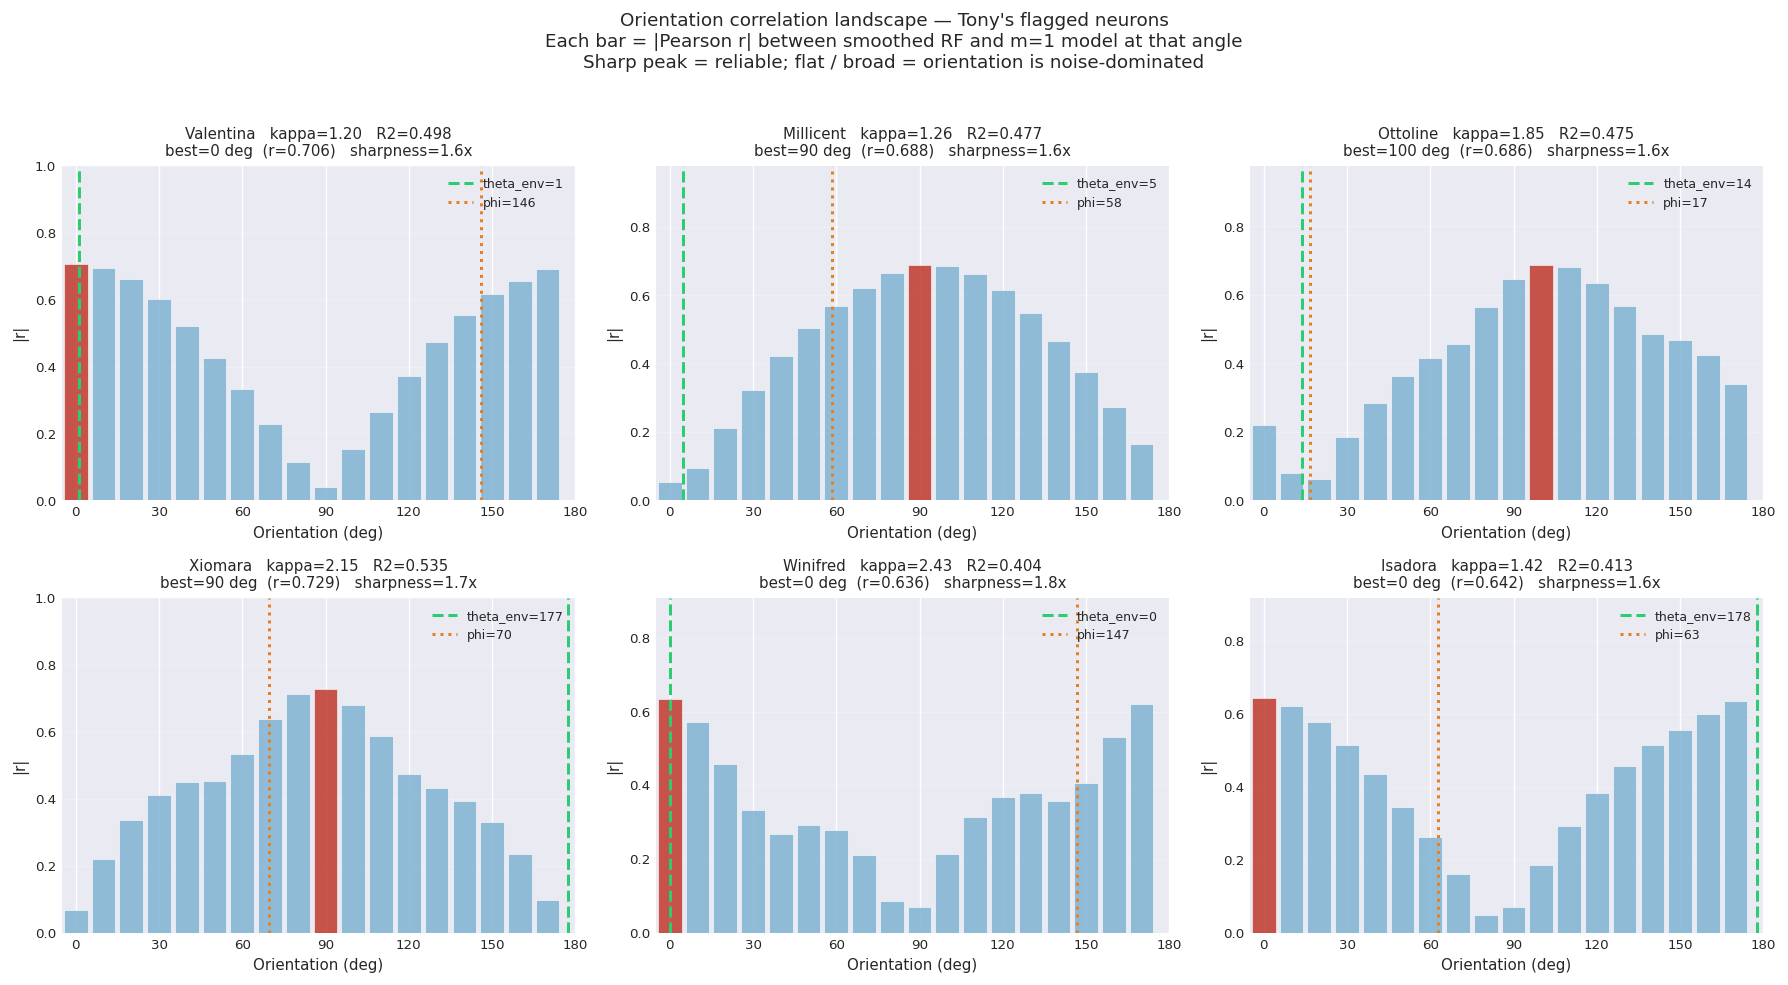

Saved to /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_gallery/fig_orientation_landscape_flagged.png

Interpretation:
  sharpness > 2.5x  ->  peak well-defined, orientation reliable
  sharpness 1.5-2.5 ->  moderate confidence
  sharpness < 1.5   ->  landscape flat, orientation noise-dominated


In [9]:
# ---------------------------------------------------------------------------
# Orientation correlation landscape — neurons flagged by Tony (June 2026)
#
# For each flagged neuron: bar chart of |Pearson r| vs smoothed RF at each
# 10-degree step.  A clear peak at the winning angle = reliable estimate;
# a flat or ambiguous landscape = orientation is noise-dominated.
#
# Tony flagged: Valentina (#9), Millicent (#17), Ottoline (#23),
#               Xiomara (#25), Winifred (#27), Isadora (#29)
# ---------------------------------------------------------------------------

FLAGGED_NAMES = ['Valentina', 'Millicent', 'Ottoline',
                 'Xiomara',   'Winifred',  'Isadora']

# name -> cell_id
name_to_cid = {v: k for k, v in name_map.items()}

ANGLES = np.arange(0, 180, 10)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='white')
fig.suptitle(
    "Orientation correlation landscape — Tony's flagged neurons\n"
    "Each bar = |Pearson r| between smoothed RF and m=1 model at that angle\n"
    "Sharp peak = reliable; flat / broad = orientation is noise-dominated",
    fontsize=11, y=1.02
)

for ax, name in zip(axes.flat, FLAGGED_NAMES):
    cid  = name_to_cid[name]
    p, q, fitted, pix, phi_fresh, phi_conf, acp = fit_results[cid]

    best_idx   = int(np.nanargmax(acp))
    best_angle = float(ANGLES[best_idx])
    best_corr  = float(np.nanmax(acp))

    colours = ['#c0392b' if i == best_idx else '#7fb3d3'
               for i in range(len(ANGLES))]
    ax.bar(ANGLES, acp, width=8.5, color=colours, alpha=0.85,
           align='center', edgecolor='white', linewidth=0.4)

    ax.axvline(float(p['theta']) % 180, color='#2ecc71', lw=1.8,
               ls='--', label=f'theta_env={float(p["theta"]) % 180:.0f}')
    if phi_fresh is not None and not np.isnan(float(phi_fresh)):
        ax.axvline(float(phi_fresh) % 180, color='#e67e22', lw=1.8,
                   ls=':', label=f'phi={float(phi_fresh) % 180:.0f}')

    ax.set_xlim(-5, 180)
    ax.set_ylim(0, min(1.0, best_corr * 1.35 + 0.05))
    ax.set_xticks(np.arange(0, 181, 30))
    ax.set_xlabel('Orientation (deg)', fontsize=9)
    ax.set_ylabel('|r|', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(axis='y', alpha=0.25)

    sharpness = (best_corr / float(np.nanmean(acp))
                 if np.nanmean(acp) > 0 else 0)

    ax.set_title(
        f'{name}   kappa={p["kappa"]:.2f}   R2={q["r_squared"]:.3f}\n'
        f'best={best_angle:.0f} deg  (r={best_corr:.3f})   '
        f'sharpness={sharpness:.1f}x',
        fontsize=9
    )

plt.tight_layout()
out = gallery_dir / 'fig_orientation_landscape_flagged.png'
plt.savefig(out, dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved to {out}')
print()
print('Interpretation:')
print('  sharpness > 2.5x  ->  peak well-defined, orientation reliable')
print('  sharpness 1.5-2.5 ->  moderate confidence')
print('  sharpness < 1.5   ->  landscape flat, orientation noise-dominated')


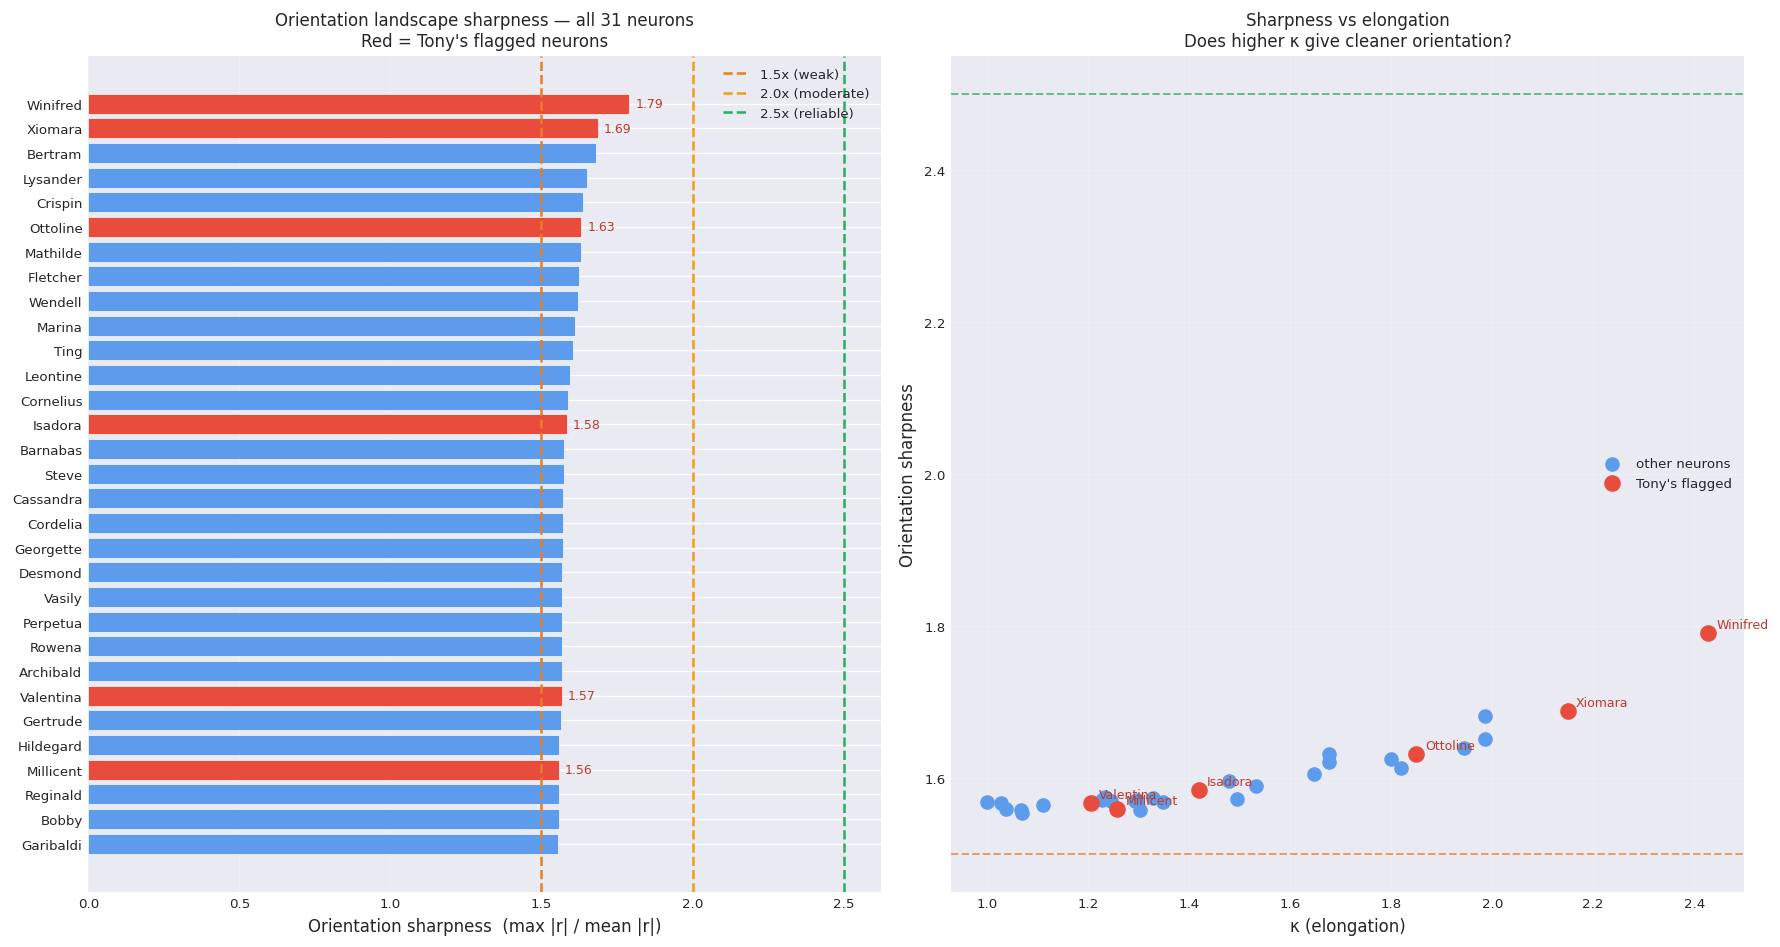

Saved → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_gallery/fig_orientation_sharpness_all.png

     name    kappa  sharpness  flagged
 Winifred 2.427887   1.790664     True
  Xiomara 2.149495   1.687105     True
  Bertram 1.985068   1.680572    False
 Lysander 1.985275   1.650095    False
  Crispin 1.943461   1.638563    False
 Ottoline 1.850033   1.631400     True
 Mathilde 1.677704   1.631012    False
 Fletcher 1.800083   1.625033    False
  Wendell 1.677620   1.620730    False
   Marina 1.818798   1.612215    False
     Ting 1.647091   1.605045    False
 Leontine 1.479367   1.595951    False
Cornelius 1.533169   1.588327    False
  Isadora 1.418877   1.583171     True
 Barnabas 1.234391   1.574280    False
    Steve 1.329166   1.573370    False
Cassandra 1.494872   1.571200    False
 Cordelia 1.296111   1.570701    False
Georgette 1.227133   1.569952    False
  Desmond 1.292631   1.569365    False
   Vasily 1.245663   1.568663    Fal

In [10]:
# ---------------------------------------------------------------------------
# Orientation sharpness — all 31 neurons
#
# sharpness = max(|r|) / mean(|r|) across the 18-step angle grid.
# Values near 1.0 = flat landscape (orientation unreliable).
# High values = clear peak (orientation well-constrained).
# Tony's flagged neurons are highlighted to see if they are outliers.
# ---------------------------------------------------------------------------

FLAGGED = ['Valentina', 'Millicent', 'Ottoline', 'Xiomara', 'Winifred', 'Isadora']

# Build sharpness table from dataset
sharp_rows = []
for r in m1_dataset:
    acp = np.array(r['angle_corr_profile'])
    sh  = float(np.nanmax(acp) / np.nanmean(acp)) if np.nanmean(acp) > 0 else 0.0
    sharp_rows.append({'name': r['name'], 'sharpness': sh,
                       'kappa': r['kappa'], 'flagged': r['name'] in FLAGGED})

sharp_df = pd.DataFrame(sharp_rows).sort_values('sharpness', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 8), facecolor='white')

# ── Left: horizontal bar chart sorted by sharpness ───────────────────────
ax = axes[0]
colours = ['#e74c3c' if r['flagged'] else '#5d9cec' for _, r in sharp_df.iterrows()]
bars = ax.barh(sharp_df['name'], sharp_df['sharpness'],
               color=colours, edgecolor='white', linewidth=0.4)

ax.axvline(1.5, color='#e67e22', lw=1.5, ls='--', label='1.5x (weak)')
ax.axvline(2.0, color='#f39c12', lw=1.5, ls='--', label='2.0x (moderate)')
ax.axvline(2.5, color='#27ae60', lw=1.5, ls='--', label='2.5x (reliable)')

ax.set_xlabel('Orientation sharpness  (max |r| / mean |r|)', fontsize=10)
ax.set_title('Orientation landscape sharpness — all 31 neurons\n'
             'Red = Tony\'s flagged neurons', fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.25)
ax.tick_params(labelsize=8)

# label the flagged ones
for _, row in sharp_df[sharp_df['flagged']].iterrows():
    ax.text(row['sharpness'] + 0.02, row['name'],
            f'{row["sharpness"]:.2f}', va='center', fontsize=7.5, color='#c0392b')

# ── Right: sharpness vs kappa scatter ────────────────────────────────────
ax2 = axes[1]
non_flag = sharp_df[~sharp_df['flagged']]
flag_df  = sharp_df[sharp_df['flagged']]

ax2.scatter(non_flag['kappa'], non_flag['sharpness'],
            color='#5d9cec', s=60, zorder=3, label='other neurons')
ax2.scatter(flag_df['kappa'], flag_df['sharpness'],
            color='#e74c3c', s=80, zorder=4, label="Tony's flagged")

for _, row in flag_df.iterrows():
    ax2.annotate(row['name'], (row['kappa'], row['sharpness']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7.5, color='#c0392b')

ax2.axhline(1.5, color='#e67e22', lw=1.2, ls='--', alpha=0.7)
ax2.axhline(2.5, color='#27ae60', lw=1.2, ls='--', alpha=0.7)
ax2.set_xlabel('κ (elongation)', fontsize=10)
ax2.set_ylabel('Orientation sharpness', fontsize=10)
ax2.set_title('Sharpness vs elongation\nDoes higher κ give cleaner orientation?', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)
ax2.tick_params(labelsize=8)

plt.tight_layout()
out = gallery_dir / 'fig_orientation_sharpness_all.png'
plt.savefig(out, dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')
print()
print(sharp_df[['name','kappa','sharpness','flagged']].sort_values(
    'sharpness', ascending=False).to_string(index=False))


In [11]:
# ---------------------------------------------------------------------------
# Paper figures — 4-panel RF sheets for all 31 neurons (Tony's request)
#
# Output:
#   m1_rf_panels_all.pdf   — one page per neuron, send to Tony/paper
#   eps/neuron_NAME.eps    — individual EPS files for each neuron
#
# Panels (NO orientation bars per Tony's request):
#   top-left:     raw RF
#   top-right:    smoothed RF (sigma=0.75)
#   bottom-left:  smoothed low-contrast + model contours
#   bottom-right: model (m=1 Gaussian derivative)
# ---------------------------------------------------------------------------
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import gaussian_filter as _gf

CMAP     = 'RdBu_r'
EPS_DIR  = gallery_dir / 'eps'
EPS_DIR.mkdir(exist_ok=True)

pdf_path = gallery_dir / 'm1_rf_panels_all.pdf'

# Sort neurons for the PDF: kappa ascending (same as Fig 1)
sorted_for_paper = sorted(m1_dataset, key=lambda r: r['kappa'])

with PdfPages(pdf_path) as pdf:
    for r in sorted_for_paper:
        rf_raw     = r['rf_raw']
        rf_smooth  = r['rf_smooth']
        rf_display = r['rf_display']
        model_map  = r['model_map']
        vmax       = r['vmax']
        m_peak     = r['model_abs_max']

        fig, axes = plt.subplots(2, 2, figsize=(8, 5.5))
        fig.patch.set_facecolor('white')

        imkw  = dict(cmap=CMAP, vmin=-vmax, vmax=vmax,
                     origin='lower', aspect='equal', interpolation='nearest')

        # (0,0) raw RF
        axes[0,0].imshow(rf_raw, **imkw)
        axes[0,0].set_title('raw RF', fontsize=9, pad=3)

        # (0,1) smoothed RF
        axes[0,1].imshow(rf_smooth, **imkw)
        axes[0,1].set_title(f'smoothed RF  (sigma=0.75)', fontsize=9, pad=3)

        # (1,0) low-contrast smoothed + model contours — NO bar
        axes[1,0].imshow(rf_display,
                         cmap=CMAP, vmin=-vmax*2.5, vmax=vmax*2.5,
                         origin='lower', aspect='equal', interpolation='nearest')
        if m_peak > 1e-9:
            fracs  = r['contour_fracs']
            levels = sorted([-f*m_peak for f in fracs] + [f*m_peak for f in fracs])
            try:
                axes[1,0].contour(model_map, levels=levels, cmap=CMAP,
                                  linewidths=1.1, alpha=0.9,
                                  vmin=-m_peak, vmax=m_peak, origin='lower')
            except Exception:
                pass
        axes[1,0].set_title('smoothed (low contrast) + model contours', fontsize=9, pad=3)

        # (1,1) model only — NO bar
        m_vmax = max(m_peak, 1e-9)
        axes[1,1].imshow(model_map,
                         cmap=CMAP, vmin=-m_vmax, vmax=m_vmax,
                         origin='lower', aspect='equal', interpolation='nearest')
        axes[1,1].set_title('model  (m=1 Gaussian derivative)', fontsize=9, pad=3)

        # Clean up axes
        for ax in axes.flat:
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_edgecolor('#bbbbbb'); sp.set_linewidth(0.6)

        # Page header
        cre_short = (r['cre_line']
                     .replace('Cux2-CreERT2','Cux2')
                     .replace('Slc17a7-IRES2-Cre','Slc17a7'))
        depth = f"{r['imaging_depth_um']} um" if r['imaging_depth_um'] else ''
        fig.suptitle(
            f"{r['name']}  —  cell {r['cell_id']}  |  {cre_short}  {depth}\n"
            f"sigma={r['sigma_deg']:.2f} deg    kappa={r['kappa']:.3f}    "
            f"theta={r['theta_envelope']:.1f} deg    R2={r['r_squared']:.3f}    "
            f"orientation sharpness={r['orientation_sharpness']:.2f}x",
            fontsize=9, y=1.01
        )

        fig.tight_layout(pad=0.6)
        pdf.savefig(fig, bbox_inches='tight', facecolor='white')

        # Also save individual EPS
        eps_path = EPS_DIR / f"neuron_{r['name']}.eps"
        fig.savefig(eps_path, format='eps', bbox_inches='tight', facecolor='white')

        plt.close(fig)

print(f"PDF  -> {pdf_path}")
print(f"EPS  -> {EPS_DIR}  ({len(sorted_for_paper)} files)")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

PDF  -> /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_gallery/m1_rf_panels_all.pdf
EPS  -> /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_gallery/eps  (31 files)
